In [2]:
# punto 3 medidas estadisticas descriptivas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fijar semilla para reproducibilidad exacta
np.random.seed(42)

n_estudiantes = 100
horas_estudio = np.random.normal(loc=12.0, scale=3.5, size=n_estudiantes)
horas_estudio = np.clip(horas_estudio, 2.0, 25.0)

puntaje_examen = 35 + 3.2 * horas_estudio + np.random.normal(loc=0.0, scale=5.0, size=n_estudiantes)
puntaje_examen = np.clip(puntaje_examen, 0.0, 100.0)

df_estudiantes = pd.DataFrame({
    'Horas_Estudio_Semana': horas_estudio,
    'Puntaje_Examen': puntaje_examen
})

media_horas = np.mean(df_estudiantes['Horas_Estudio_Semana'])
mediana_horas = np.median(df_estudiantes['Horas_Estudio_Semana'])
desv_horas = np.std(df_estudiantes['Horas_Estudio_Semana'], ddof=1)

media_puntaje = np.mean(df_estudiantes['Puntaje_Examen'])
mediana_puntaje = np.median(df_estudiantes['Puntaje_Examen'])
desv_puntaje = np.std(df_estudiantes['Puntaje_Examen'], ddof=1)

print(f"Horas de Estudio Semanales -> Media: {media_horas:.2f}, Mediana: {mediana_horas:.2f}, Desv. Estándar: {desv_horas:.2f}")
print(f"Puntaje del Examen (0-100)  -> Media: {media_puntaje:.2f}, Mediana: {mediana_puntaje:.2f}, Desv. Estándar: {desv_puntaje:.2f}")

Horas de Estudio Semanales -> Media: 11.64, Mediana: 11.56, Desv. Estándar: 3.18
Puntaje del Examen (0-100)  -> Media: 72.34, Mediana: 71.70, Desv. Estándar: 10.61


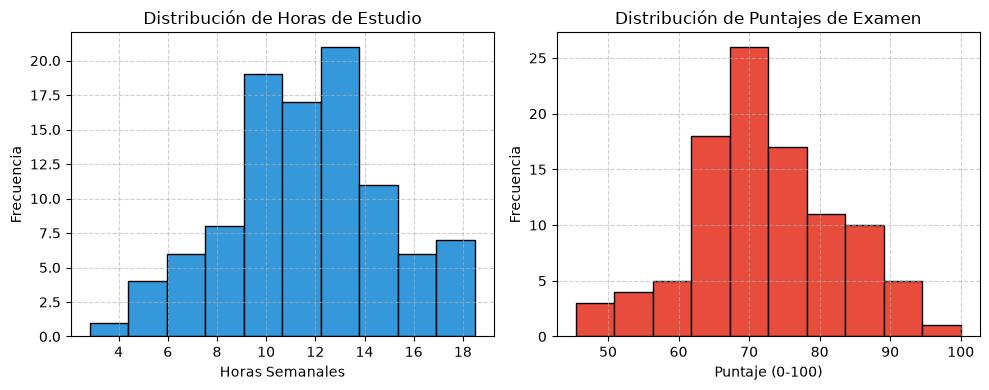

In [3]:
# punto 4 vizualizacion grafica exploratoria
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_estudiantes['Horas_Estudio_Semana'], bins=10, color='#3498db', edgecolor='black')
plt.title('Distribución de Horas de Estudio')
plt.xlabel('Horas Semanales')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.hist(df_estudiantes['Puntaje_Examen'], bins=10, color='#e74c3c', edgecolor='black')
plt.title('Distribución de Puntajes de Examen')
plt.xlabel('Puntaje (0-100)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('distribucion_variables.png', dpi=300)
plt.show()

In [4]:
# punto 6 Implementación de regresión lineal (numpy.polyfit)

x = df_estudiantes['Horas_Estudio_Semana'].to_numpy()
y = df_estudiantes['Puntaje_Examen'].to_numpy()

m, b = np.polyfit(x, y, 1)
correlacion = np.corrcoef(x, y)[0, 1]

print(f"Pendiente (m): {m:.4f}")
print(f"Intercepto (b): {b:.4f}")
print(f"Ecuación del modelo: Puntaje = {m:.2f} * Horas + {b:.2f}")
print(f"Coeficiente de correlación de Pearson (r): {correlacion:.4f}")

Pendiente (m): 2.9923
Intercepto (b): 37.5233
Ecuación del modelo: Puntaje = 2.99 * Horas + 37.52
Coeficiente de correlación de Pearson (r): 0.8961


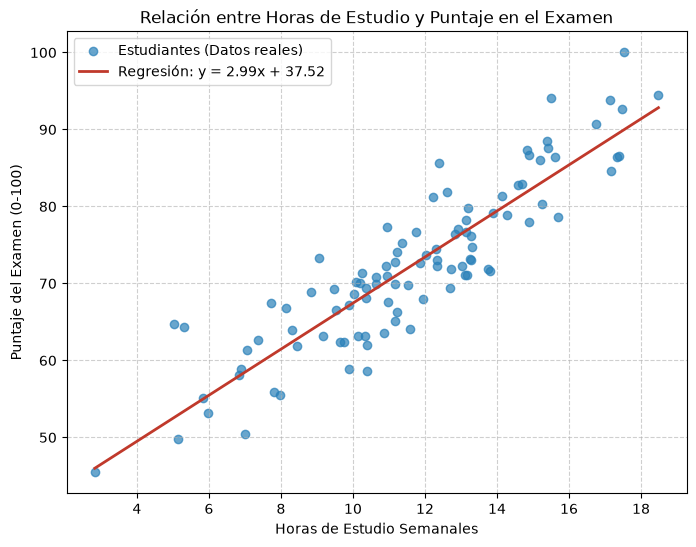

In [5]:
# punto 7 Gráfico de dispersión y línea de tendencia

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='#2980b9', alpha=0.7, label='Estudiantes (Datos reales)')

x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

plt.plot(x_linea, y_linea, color='#c0392b', linewidth=2, label=f'Regresión: y = {m:.2f}x + {b:.2f}')
plt.title('Relación entre Horas de Estudio y Puntaje en el Examen')
plt.xlabel('Horas de Estudio Semanales')
plt.ylabel('Puntaje del Examen (0-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('regresion_lineal.png', dpi=300)
plt.show()